In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix


In [ ]:

file_path = '/kaggle/input/predict-ovarian-cancer/Supplementary data 1.xlsx'
df = pd.read_excel(file_path)
print("Data loaded successfully.")

# Drop SUBJECT_ID as done in the notebook
if 'SUBJECT_ID' in df.columns:
    df.drop('SUBJECT_ID', axis=1, inplace=True)

# Identify object columns among potential tumor markers
object_columns_in_markers = df[['AFP', 'CA125', 'CA19-9', 'CA72-4', 'CEA', 'HE4']].select_dtypes(include=['object']).columns.tolist()
print(f"Object columns to clean in markers: {object_columns_in_markers}")


Data loaded successfully.
Object columns to clean in markers: ['AFP', 'CA125', 'CA19-9']


In [ ]:

# Using the cleaning function defined in the notebook
def clean_numeric_columns(df_in, columns):
    df_out = df_in.copy()
    
    def clean_value(x):
        if pd.isna(x):
            return np.nan
        if isinstance(x, (int, float)):
            return float(x)
        if isinstance(x, str):
            cleaned = re.sub(r'\\t|\s+', '', x)
            try:
                return float(cleaned)
            except ValueError:
                return np.nan
        return np.nan
    
    for col in columns:
        df_out[col] = df_out[col].apply(clean_value).astype(float)
    return df_out

df_cleaned = clean_numeric_columns(df, object_columns_in_markers)
print("Numeric columns cleaned.")


Numeric columns cleaned.


In [ ]:

# Biomarker distribution settings
BIOMARKER_DISTRIBUTIONS = {
    'AFP': {'mean': 5, 'std': 2.5, 'units': 'ng/mL'},
    'CA125': {'mean': 17, 'std': 9, 'units': 'U/mL'},
    'CA19-9': {'mean': 18, 'std': 9.5, 'units': 'U/mL'},
    'CA72-4': {'mean': 3.5, 'std': 1.7, 'units': 'U/mL'},
    'HE4': {'mean': 70, 'std': 20, 'units': 'pmol/L'},
    'AG': {'mean': 12, 'std': 2, 'units': 'mEq/L'},
    'ALB': {'mean': 4.4, 'std': 0.5, 'units': 'g/dL'},
    'ALP': {'mean': 80, 'std': 30, 'units': 'IU/L'},
    'ALT': {'mean': 30, 'std': 12, 'units': 'IU/L'},
    'AST': {'mean': 28, 'std': 10, 'units': 'IU/L'},
    'CO2CP': {'mean': 26, 'std': 1.5, 'units': 'mEq/L'},
    'DBIL': {'mean': 0.15, 'std': 0.1, 'units': 'mg/dL'},
    'GGT': {'mean': 15, 'std': 7, 'units': 'U/L'},
    'GLO': {'mean': 2.9, 'std': 0.3, 'units': 'g/dL'},
    'IBIL': {'mean': 0.5, 'std': 0.2, 'units': 'mg/dL'},
    'MPV': {'mean': 9.5, 'std': 1, 'units': 'fL'},
    'NEU': {'mean': 4.75, 'std': 1.5, 'units': '10^3/μL'},
    'PCT': {'mean': 0.1, 'std': 0.2, 'units': 'ng/mL'},
    'PDW': {'mean': 13, 'std': 2, 'units': '%'},
    'TBIL': {'mean': 0.75, 'std': 0.3, 'units': 'mg/dL'},
    'TP': {'mean': 7.15, 'std': 0.5, 'units': 'g/dL'}
}

def generate_biomarker_imputation(df_in, biomarkers=None, seed=42):
    imputed_df_out = df_in.copy()
    np.random.seed(seed)
    
    if biomarkers is None:
        biomarkers = list(BIOMARKER_DISTRIBUTIONS.keys())
    
    imputation_details_out = {}
    
    for marker in biomarkers:
        if marker not in imputed_df_out.columns or not imputed_df_out[marker].isna().any():
            continue
        
        dist_params = BIOMARKER_DISTRIBUTIONS[marker]
        missing_mask = imputed_df_out[marker].isna()
        n_missing = missing_mask.sum()
        
        impute_values = np.random.normal(
            loc=dist_params['mean'],
            scale=dist_params['std'],
            size=n_missing
        )
        impute_values[impute_values < 0] = 0  # Ensure non-negative
        imputed_df_out.loc[missing_mask, marker] = impute_values
        
        imputation_details_out[marker] = {
            'n_imputed': n_missing,
            'imputation_mean': dist_params['mean'],
            'imputation_std': dist_params['std'],
            'units': dist_params['units']
        }
    
    return imputed_df_out, imputation_details_out

# Define the tumor marker columns
tumor_markers = ['AFP', 'CA125', 'CA19-9', 'CA72-4', 'CEA', 'HE4']

# Impute missing values only for tumor markers defined in BIOMARKER_DISTRIBUTIONS
markers_to_impute = [m for m in tumor_markers if m in BIOMARKER_DISTRIBUTIONS and df_cleaned[m].isnull().any()]
df_imputed, details = generate_biomarker_imputation(df_cleaned, biomarkers=markers_to_impute)
print("Imputation details (Normal Distribution):", details)

# Impute remaining NaNs in tumor markers (like CEA if not in distributions) with mean
for col in tumor_markers:
    if df_imputed[col].isnull().any():
        mean_val = df_imputed[col].mean()
        df_imputed[col].fillna(mean_val, inplace=True)
        print(f"Filled remaining NaNs in '{col}' with mean: {mean_val:.4f}")


Imputation details (Normal Distribution): {'AFP': {'n_imputed': 24, 'imputation_mean': 5, 'imputation_std': 2.5, 'units': 'ng/mL'}, 'CA125': {'n_imputed': 19, 'imputation_mean': 17, 'imputation_std': 9, 'units': 'U/mL'}, 'CA19-9': {'n_imputed': 34, 'imputation_mean': 18, 'imputation_std': 9.5, 'units': 'U/mL'}, 'CA72-4': {'n_imputed': 240, 'imputation_mean': 3.5, 'imputation_std': 1.7, 'units': 'U/mL'}, 'HE4': {'n_imputed': 20, 'imputation_mean': 70, 'imputation_std': 20, 'units': 'pmol/L'}}
Filled remaining NaNs in 'CEA' with mean: 3.3091


/tmp/ipykernel_31/2200875962.py:74: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed[col].fillna(mean_val, inplace=True)


In [ ]:


X = df_imputed[tumor_markers]
y = df_imputed['TYPE']  # Target variable

print("\nFeature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Class distribution:\n", y.value_counts())

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features scaled.")



Feature matrix shape: (349, 6)
Target vector shape: (349,)
Class distribution:
 TYPE
1    178
0    171
Name: count, dtype: int64
Features scaled.


In [ ]:

# Using RandomForest for robustness and built-in class weighting
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("\nTraining Random Forest model on Tumor Markers...")
rf_model.fit(X_train_scaled, y_train)



Training Random Forest model on Tumor Markers...


RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)


Evaluating model...
Test Accuracy: 0.9000
Test Balanced Accuracy: 0.9003

Classification Report:
                 precision    recall  f1-score   support

        Benign       0.89      0.91      0.90        34
Ovarian Cancer       0.91      0.89      0.90        36

      accuracy                           0.90        70
     macro avg       0.90      0.90      0.90        70
  weighted avg       0.90      0.90      0.90        70



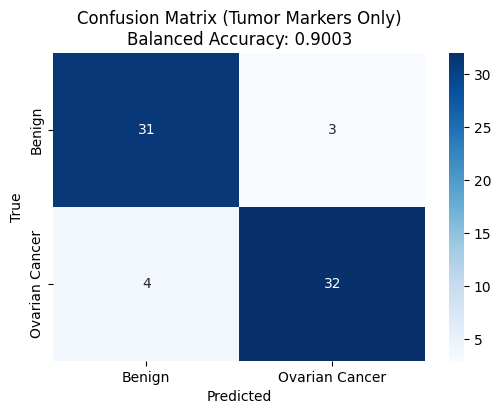

In [ ]:

print("\nEvaluating model...")
y_pred = rf_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(
    y_test, y_pred, target_names=['Benign', 'Ovarian Cancer']
)  # Assuming 0=Benign, 1=Cancer

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Balanced Accuracy: {balanced_accuracy:.4f}")
print("\nClassification Report:\n", report)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Benign', 'Ovarian Cancer'],
    yticklabels=['Benign', 'Ovarian Cancer']
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix (Tumor Markers Only)\nBalanced Accuracy: {balanced_accuracy:.4f}')
plt.show()


---
---
---

In [8]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras import layers, regularizers, callbacks, models, losses, metrics
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

2025-04-29 14:45:04.556340: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745937904.831598      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745937904.907388      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [9]:


print("Using pre-processed data:")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_test shape: {y_test.shape}")


Using pre-processed data:
X_train_scaled shape: (279, 6)
y_train shape: (279,)
X_test_scaled shape: (70, 6)
y_test shape: (70,)


In [10]:

# --- Define Binary Focal Loss (Optional, can use 'binary_crossentropy') ---
# Adapting the previous focal loss for binary classification
def binary_focal_loss(gamma=2.0, alpha=0.25):
    """
    Binary form of focal loss.
    """
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32) # Ensure y_true is float
        # Calculate Binary Crossentropy
        bce = losses.binary_crossentropy(y_true, y_pred)

        # Calculate Focal Loss components
        p_t = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        alpha_factor = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)
        modulating_factor = tf.pow(1.0 - p_t, gamma)

        # Return the final Focal Loss
        return tf.reduce_mean(alpha_factor * modulating_factor * bce)
    return focal_loss_fixed

# --- Build the DL Model (Adapted from first notebook) ---
def build_tumor_marker_model(input_shape, num_classes=1): # num_classes=1 for binary
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(), # Added BatchNormalization
        layers.Dropout(0.3), # Adjusted dropout slightly
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.1),
        # Output layer for BINARY classification
        layers.Dense(num_classes, activation='sigmoid', name='output_layer')
    ])
    return model


In [11]:

# Get input shape from the training data
input_dims = X_train_scaled.shape[1]

# Instantiate the model
dl_model = build_tumor_marker_model((input_dims,))
dl_model.summary()


2025-04-29 14:45:19.649895: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,161 (47.50 KB)

 Trainable params: 11,713 (45.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [12]:

# --- Compile the Model ---
dl_model.compile(
    # optimizer=AdamW(learning_rate=1e-4, weight_decay=1e-5), # Start with potentially lower LR
    optimizer=AdamW(learning_rate=0.0005, weight_decay=0.0001), # Adjusted learning rate and decay
    # loss=binary_focal_loss(gamma=2.0, alpha=0.25), # Use custom binary focal loss
    loss='binary_crossentropy', # Or use standard binary crossentropy
    metrics=[
        'accuracy',
        metrics.AUC(name='auc'), # Area Under the ROC Curve
        metrics.Precision(name='precision'),
        metrics.Recall(name='recall')
    ]
)

# --- Define Callbacks ---
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=15,        # Increase patience slightly
    restore_best_weights=True,
    mode='min'
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6,
    mode='min'
)


In [13]:

# --- Train the Model ---
print("\nTraining DL model on Tumor Markers...")
history = dl_model.fit(
    X_train_scaled,
    y_train,
    epochs=100, # Set a higher number, early stopping will control the actual duration
    batch_size=32,
    validation_data=(X_test_scaled, y_test), # Use the test set as validation here
    callbacks=[early_stop, reduce_lr],
    verbose=1 # Set to 1 or 2 for progress, 0 for silent
)



Training DL model on Tumor Markers...
Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - accuracy: 0.4605 - auc: 0.4875 - loss: 0.8924 - precision: 0.4439 - recall: 0.4833 - val_accuracy: 0.7143 - val_auc: 0.8652 - val_loss: 0.6835 - val_precision: 0.6429 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5662 - auc: 0.5758 - loss: 0.8061 - precision: 0.5925 - recall: 0.6826 - val_accuracy: 0.6571 - val_auc: 0.9150 - val_loss: 0.6803 - val_precision: 0.6000 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6477 - auc: 0.6883 - loss: 0.6734 - precision: 0.6139 - recall: 0.8343 - val_accuracy: 0.6429 - val_auc: 0.8971 - val_loss: 0.6779 - val_precision: 0.5902 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6468 - auc: 0.7088 - loss: 0.6476 - precision: 0.6090 - recall: 0.7953 - val_accuracy: 0.6429 -

In [14]:

# --- Evaluate Model ---
print("\nEvaluating DL model...")
loss, accuracy, auc, precision, recall = dl_model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test AUC: {auc:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")



Evaluating DL model...
Test Loss: 0.6078
Test Accuracy: 0.6143
Test AUC: 0.9449
Test Precision: 1.0000
Test Recall: 0.2500


In [15]:

# Get probability predictions for more detailed metrics
y_pred_proba = dl_model.predict(X_test_scaled).flatten() # Flatten needed for binary output
y_pred_class = (y_pred_proba > 0.5).astype(int) # Convert probabilities to 0 or 1

# Calculate additional metrics
balanced_accuracy = balanced_accuracy_score(y_test, y_pred_class)
cm = confusion_matrix(y_test, y_pred_class)
report = classification_report(y_test, y_pred_class, target_names=['Benign', 'Ovarian Cancer'])

print(f"Test Balanced Accuracy: {balanced_accuracy:.4f}")
print("\nClassification Report:\n", report)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step
Test Balanced Accuracy: 0.6250

Classification Report:
                 precision    recall  f1-score   support

        Benign       0.56      1.00      0.72        34
Ovarian Cancer       1.00      0.25      0.40        36

      accuracy                           0.61        70
     macro avg       0.78      0.62      0.56        70
  weighted avg       0.79      0.61      0.55        70



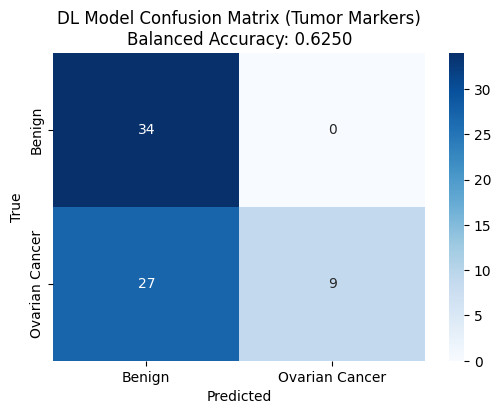

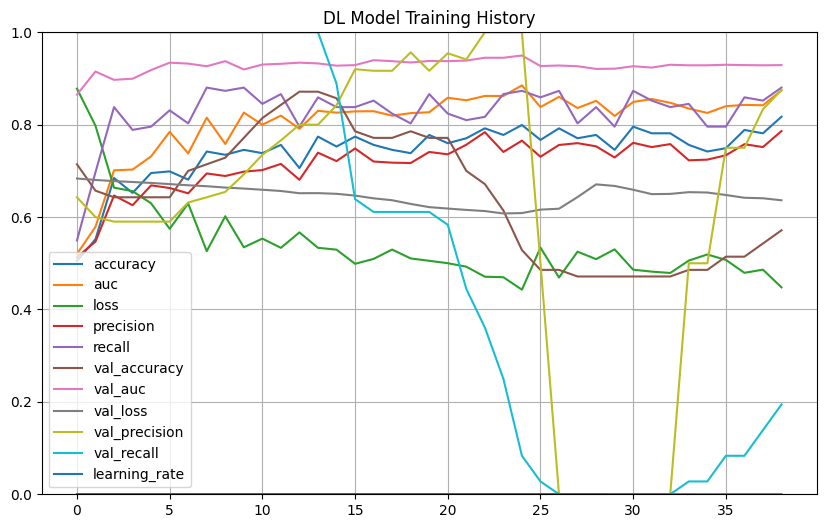

In [16]:

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Ovarian Cancer'],
            yticklabels=['Benign', 'Ovarian Cancer'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'DL Model Confusion Matrix (Tumor Markers)\nBalanced Accuracy: {balanced_accuracy:.4f}')
plt.show()

# Plot training history (optional)
pd.DataFrame(history.history).plot(figsize=(10, 6))
plt.grid(True)
plt.gca().set_ylim(0, 1) # Adjust y-axis limits if needed
plt.title('DL Model Training History')
plt.show()

In [20]:
import joblib
import sklearn # Ensure sklearn is imported if not already

# Assuming 'rf_model' is your trained RF classifier for tumor markers
# Assuming 'scaler' is the MinMaxScaler fit on the tumor marker training data

# Save the model
joblib.dump(rf_model, '/kaggle/working/rf_model_tumor_markers.joblib')
print("Tumor marker RF model saved as rf_model_tumor_markers.joblib")

# Save the scaler
joblib.dump(scaler, '/kaggle/working/scaler_tumor_markers.joblib')
print("Tumor marker scaler saved as scaler_tumor_markers.joblib")

Tumor marker RF model saved as rf_model_tumor_markers.joblib
Tumor marker scaler saved as scaler_tumor_markers.joblib
